# <font color='#03AED2'>This notebook is for Malmquist bias model</font>
This notebook takes the measured luminosities from notebook 1-b and uses them to model and justify the Malmquist bias correction.
- Grabs the data from 1-b
- Make histogram for number of sources per luminosity bin
- Find the distribution of AGN at each redshift (the spread)
    - The spread should be the same for each of the redshifts, but the averages will be different.
- Start with the spread of 0.25-0.35
    - Use the average
    - Assume a scatter
    - Sample from this distribution
    - Keep anything above the flux limit of the telescope
- Find the number density of AGN per redshift
- Find the AGN luminosity function
    - Chenxu's paper ... Figure 10 ... K19
 


<hr style="border:2px solid #84B179">

# <font color='#FE81D4' size=5 >Values</font>

In [1]:
Colors = {"Purple": "#a714ff",
          "Pink": "#ff14f5",
          "Teal": "#14D8FF",
          "Blue": "#60B5FF",
          "Green": "#00FF9C",
          "Orange": "#ffbb14",
          "Red": "#FF5757"
          
}

HETDEX_Flux_Limit = 3.5*10**-17 #erg/s/cm²


#The Parameters from the paper for model one.
coeffs = {
'c0_0': {'value': -7.798,   'err_up': 0.145,  'err_lo': 0.157},
'c0_1': {'value':  1.128,   'err_up': 0.085,  'err_lo': 0.081},
'c0_2': {'value': -0.120,   'err_up': 0.005,  'err_lo': 0.006},
'c1_0': {'value': -17.163,  'err_up': 0.219,  'err_lo': 0.226},
'c1_1': {'value': -5.512,   'err_up': 0.127,  'err_lo': 0.124},
'c1_2': {'value':  0.593,   'err_up': 0.011,  'err_lo': 0.010},
'c1_3': {'value': -0.024,   'err_up': 0.00038,'err_lo': 0.00039},
'c2_0': {'value': -3.223,   'err_up': 0.127,  'err_lo': 0.121},
'c2_1': {'value': -0.258,   'err_up': 0.047,  'err_lo': 0.051},
'c3_0': {'value': -2.312,   'err_up': 0.034,  'err_lo': 0.032},
'c3_1': {'value':  0.559,   'err_up': 0.049,  'err_lo': 0.045},
'c3_2': {'value':  3.773,   'err_up': 0.017,  'err_lo': 0.016},
'c3_3': {'value':  141.884, 'err_up': 31.521, 'err_lo': 8.832},
'c3_4': {'value': -0.171,   'err_up': 0.101,  'err_lo': 0.116},
}

# <font color='#FE81D4' size=5 >Imports</font>

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import biweight_location, biweight_scale
from astropy.table import QTable, Table, Column



from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [3]:
def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    if auto_assign:
        # Automatically assign variables to global namespace
        import inspect
        frame = inspect.currentframe()
        try:
            # Get the caller's globals (the notebook's global namespace)
            caller_globals = frame.f_back.f_globals
            
            # Assign each variable to the caller's global namespace
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables to global namespace")
            print("Sample variables now available:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:  # Show first 3
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
                    
        finally:
            del frame
    
    return vars_dict


def Kulkarni_AGN_UV_luminosity(redshift, magnitudes):
    """
    This function uses the Kulkarni et al. (2019) AGN UV Luminosity function. PAPER=>> https://arxiv.org/pdf/1807.09774
    We are using Model One for our work: 1.) Least complex. 2.) Fits the best. 3.) Our data falls below the issue that this model presents at z=3.5.

    Parameters
    ----------
    redshifts: array
        This is an array of redshifts for the sample.
    magnatudes: array
        This is an array of magnitudes for the sample.

    Return
    ------
    Kulkarni_AGN_UV_Luminosity: dictionary
        This are the parts of the dictionary: Log_10_Phi_Star_Z, Phi_Star_Z, M_Star_Z, Alpha_Z, Beta_Z, Phi_M. Along with errors.
    
    """

    #The parts of the overal equation (These come from Eq.13,16,and 17 in the paper
    f_0_log_10_phi_star_z = (coeffs["c0_0"]["value"] * 1 + 
                            coeffs["c0_1"]["value"] * (1+redshift) +  
                            coeffs["c0_2"]["value"] * (2*(1+redshift)**2 - 1))
    
    f_1_M_star_z = (coeffs["c1_0"]["value"] * 1 + 
                   coeffs["c1_1"]["value"] * (1+redshift) +  
                   coeffs["c1_2"]["value"] * (2*(1+redshift)**2 - 1) + 
                   coeffs["c1_3"]["value"] * (4*(1+redshift)**3 - 3* (1+redshift)))
    
    f_2_alpha_z = coeffs["c2_0"]["value"] * 1 + coeffs["c2_1"]["value"] * (1+redshift)

    
    zeta = np.log10((1+redshift) / (1 + coeffs["c3_2"]["value"]))
    denominator = (10**(coeffs["c3_3"]["value"] * zeta) +
             10**(coeffs["c3_4"]["value"] * zeta))
    f_3_beta_z = coeffs["c3_0"]["value"] + coeffs["c3_1"]["value"] / denominator

    #Turn the log10 into natural 
    f_0_phi_star_z = 10**(f_0_log_10_phi_star_z)
    
    #The main eqation (Eq.7 in the paper)
    dM_alpha = magnitudes - f_1_M_star_z
    term_alpha = 10**(0.4 * (f_2_alpha_z + 1) * dM_alpha)
    term_beta  = 10**(0.4 * (f_3_beta_z + 1) * dM_alpha)
    denom_phi  = term_alpha + term_beta
    phi_star_M = f_0_phi_star_z / denom_phi

    #Error propagation 
    f_0_log_10_phi_star_z_err_up = (np.sqrt((coeffs["c0_0"]["err_up"] * 1)**2 +
                         (coeffs["c0_1"]["err_up"] * (1+redshift))**2 +
                         (coeffs["c0_2"]["err_up"] * (2*(1+redshift)**2 - 1))**2))
    
    f_0_log_10_phi_star_z_err_lo = (np.sqrt((coeffs["c0_0"]["err_lo"] * 1)**2 +
                         (coeffs["c0_1"]["err_lo"] * (1+redshift))**2 +
                         (coeffs["c0_2"]["err_lo"] * (2*(1+redshift)**2 - 1))**2))

    
    f_1_M_star_z_err_up = (np.sqrt((coeffs["c1_0"]["err_up"] * 1)**2 +
                         (coeffs["c1_1"]["err_up"] * (1+redshift))**2 +
                         (coeffs["c1_2"]["err_up"] * (2*(1+redshift)**2 - 1))**2 +
                         (coeffs["c1_3"]["err_up"] * (4*(1+redshift)**3 - 3*(1+redshift)))**2))
    
    f_1_M_star_z_err_lo = (np.sqrt((coeffs["c1_0"]["err_lo"] * 1)**2 +
                         (coeffs["c1_1"]["err_lo"] * (1+redshift))**2 +
                         (coeffs["c1_2"]["err_lo"] * (2*(1+redshift)**2 - 1))**2 +
                         (coeffs["c1_3"]["err_lo"] * (4*(1+redshift)**3 - 3*(1+redshift)))**2))

    f_2_alpha_z_err_up = (np.sqrt((coeffs["c2_0"]["err_up"] * 1)**2 +
                         (coeffs["c2_1"]["err_up"] * (1+redshift))**2))
    
    f_2_alpha_z_err_lo = (np.sqrt((coeffs["c2_0"]["err_lo"] * 1)**2 +
                         (coeffs["c2_1"]["err_lo"] * (1+redshift))**2))

    # Error propagation for F_3 via partial derivatives
    df3_dc30 = 1.0
    df3_dc31 = 1.0 / denominator
    df3_dc32 = (-coeffs["c3_1"]["value"] / denominator**2) * np.log(10) / ((1 + coeffs["c3_2"]["value"]) * np.log(10)) * (
                coeffs["c3_3"]["value"] * 10**(coeffs["c3_3"]["value"] * zeta) +
                coeffs["c3_4"]["value"] * 10**(coeffs["c3_4"]["value"] * zeta))
    df3_dc33 = (-coeffs["c3_1"]["value"] / denominator**2) * zeta * np.log(10) * 10**(coeffs["c3_3"]["value"] * zeta)
    df3_dc34 = (-coeffs["c3_1"]["value"] / denominator**2) * zeta * np.log(10) * 10**(coeffs["c3_4"]["value"] * zeta)

    f_3_beta_z_err_up = np.sqrt((df3_dc30 * coeffs["c3_0"]["err_up"])**2 +
                         (df3_dc31 * coeffs["c3_1"]["err_up"])**2 +
                         (df3_dc32 * coeffs["c3_2"]["err_up"])**2 +
                         (df3_dc33 * coeffs["c3_3"]["err_up"])**2 +
                         (df3_dc34 * coeffs["c3_4"]["err_up"])**2)
    f_3_beta_z_err_lo = np.sqrt((df3_dc30 * coeffs["c3_0"]["err_lo"])**2 +
                         (df3_dc31 * coeffs["c3_1"]["err_lo"])**2 +
                         (df3_dc32 * coeffs["c3_2"]["err_lo"])**2 +
                         (df3_dc33 * coeffs["c3_3"]["err_lo"])**2 +
                         (df3_dc34 * coeffs["c3_4"]["err_lo"])**2)

    #Getting the error for phi_star natural 
    phi_star_z_err_up = f_0_phi_star_z * np.log(10) * f_0_log_10_phi_star_z_err_up
    phi_star_z_err_lo = f_0_phi_star_z * np.log(10) * f_0_log_10_phi_star_z_err_lo


    # Error propagation for phi(M) via partial derivatives
    dphi_dphistar = 1.0 / denom_phi
    dphi_dM1 = phi_star_M * np.log(10) * 0.4 * ((f_2_alpha_z + 1) * term_alpha + (f_3_beta_z + 1) * term_beta) / denom_phi
    dphi_dalpha = -phi_star_M * np.log(10) * 0.4 * dM_alpha * term_alpha / denom_phi
    dphi_dbeta  = -phi_star_M * np.log(10) * 0.4 * dM_alpha * term_beta  / denom_phi

    phi_star_M_err_up = np.sqrt((dphi_dphistar * phi_star_z_err_up)**2 +
                           (dphi_dM1     * f_1_M_star_z_err_up)**2 +
                           (dphi_dalpha  * f_2_alpha_z_err_up)**2 +
                           (dphi_dbeta   * f_3_beta_z_err_up)**2)
    phi_star_M_err_lo = np.sqrt((dphi_dphistar * phi_star_z_err_lo)**2 +
                           (dphi_dM1     * f_1_M_star_z_err_lo)**2 +
                           (dphi_dalpha  * f_2_alpha_z_err_lo)**2 +
                           (dphi_dbeta   * f_3_beta_z_err_lo)**2)

    
    #Putting everything into arrays
    f_0_log_10_phi_star_z_array = f_0_log_10_phi_star_z
    f_0_log_10_phi_star_z_err_up_array = f_0_log_10_phi_star_z_err_up
    f_0_log_10_phi_star_z_err_lo_array = f_0_log_10_phi_star_z_err_lo
    f_0_phi_star_z_array = f_0_phi_star_z
    phi_star_z_err_up_array = phi_star_z_err_up
    phi_star_z_err_lo_array = phi_star_z_err_lo
    f_1_M_star_z_array = f_1_M_star_z
    f_1_M_star_z_err_up_array = f_1_M_star_z_err_up
    f_1_M_star_z_err_lo_array = f_1_M_star_z_err_lo
    f_2_alpha_z_array = f_2_alpha_z
    f_2_alpha_z_err_up_array = f_2_alpha_z_err_up
    f_2_alpha_z_err_lo_array = f_2_alpha_z_err_lo
    f_3_beta_z_array = f_3_beta_z
    f_3_beta_z_err_up_array = f_3_beta_z_err_up
    f_3_beta_z_err_lo_array = f_3_beta_z_err_lo
    phi_star_M_array = phi_star_M
    phi_star_M_err_up_array = phi_star_M_err_up
    phi_star_M_err_lo_array = phi_star_M_err_lo


    #Putting into a dictionary
    Kulkarni_AGN_UV_Luminosity = {
        "Log_10_Phi_Star_Z": {"Value": f_0_log_10_phi_star_z_array, "Upper_Error": f_0_log_10_phi_star_z_err_up_array, "Lower_Error": f_0_log_10_phi_star_z_err_lo_array},
        "Phi_Star_Z":        {"Value": f_0_phi_star_z_array, "Upper_Error": phi_star_z_err_up_array, "Lower_Error": phi_star_z_err_lo_array},
        "M_Star_Z":          {"Value": f_1_M_star_z_array, "Upper_Error": f_1_M_star_z_err_up_array, "Lower_Error": f_1_M_star_z_err_lo_array},
        "Alpha_Z":           {"Value": f_2_alpha_z_array, "Upper_Error": f_2_alpha_z_err_up_array, "Lower_Error": f_2_alpha_z_err_lo_array},
        "Beta_Z":            {"Value": f_3_beta_z_array, "Upper_Error": f_3_beta_z_err_up_array, "Lower_Error": f_3_beta_z_err_lo_array},
        "Phi_M":             {"Value": phi_star_M_array, "Upper_Error": phi_star_M_err_up_array, "Lower_Error": phi_star_M_err_lo_array},
    }
    
    #Return
    return Kulkarni_AGN_UV_Luminosity


def calculate_limiting_luminosity(redshifts, flux_limit):
    """
    Calculate the limiting luminosity at each redshift.
    
    Parameters:
    -----------
    redshifts : array
        Redshifts
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    
    Returns:
    --------
    L_lim : array
        Limiting luminosity density at each redshift (erg/s/Å)
    """
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    L_lim = 4 * np.pi * d_L**2 * flux_limit
    
    return L_lim


def luminosity_to_absolute_mag(luminosity_3000_wave):
    """
    This code takes a given luminosity in wavelength and turns it to luminosity in frequency.
    Then it uses the luminosity in frequency to find the absolute magnitude using the AB mag system.

    Params
    ------
    luminosity_wave: array
        Luminosity in wavelength [erg/s/Å].

    Returns
    -------
    M_1450_array: array
        The absolute magnitudes from the input luminosities.
    """
    # Convert to array for uniform handling
    luminosity_3000_wave = np.atleast_1d(np.array(luminosity_3000_wave, dtype=float))
    
    # Step 1: L_lambda(3000) -> L_nu(3000)
    lambda_3000_cm = 3000 * 10**-8
    c_in_cm        = 3.0 * 10**10
    lum_3000_frequency = luminosity_3000_wave * lambda_3000_cm**2 / c_in_cm

    # Step 2: L_nu(3000) -> L_nu(1450)
    alpha_nu = -0.61
    lum_1450_frequency = lum_3000_frequency * (1450/3000)**alpha_nu

    # Step 3: L_nu(1450) -> M_1450
    M_1450_array = -2.5 * np.log10(lum_1450_frequency) + 51.6

    return M_1450_array


def malmquist_correction_model(redshift_indexes, step_for_derivative):
    """
    This definition is computing the Malmquist bias correction for each of the redshift bins.

    Parameters:
    -----------
    redshift_indexes: dictionary
        Redshift values and indices for each bin
    step_for_derivative: float
        Step size for numerical derivative

    Returns:
    --------
    Malmquist_Corrections : dict
        Malmquist bias correction for each redshift bin with errors
    """
    Malmquist_Corrections = {}

    for bin_name, bin_data in redshift_indexes.items():
        try:
            idx = np.array(bin_data["Index"])

            #-------------First, representative redshift for the bin.------------
            representative_redshift_per_bin = biweight_location(bin_data["Value"])

            #-------------Second, limiting absolute magnitude at the representative redshift.------------
            luminosity_limit_per_bin = calculate_limiting_luminosity(representative_redshift_per_bin, HETDEX_Flux_Limit)
            M_limit_per_bin          = luminosity_to_absolute_mag(luminosity_limit_per_bin)

            #-------------Third, numerical derivative of log Phi at M_lim.------------------
            lf_plus  = Kulkarni_AGN_UV_luminosity(representative_redshift_per_bin, M_limit_per_bin[0] + step_for_derivative)
            lf_minus = Kulkarni_AGN_UV_luminosity(representative_redshift_per_bin, M_limit_per_bin[0] - step_for_derivative)

            log_phi_plus  = np.log10(lf_plus["Phi_M"]["Value"])
            log_phi_minus = np.log10(lf_minus["Phi_M"]["Value"])
            derivative_phi_star = (log_phi_plus - log_phi_minus) / (2 * step_for_derivative)

            #-------------Fourth, error on derivative_phi_star.--------------
            log_phi_plus_err_up  = lf_plus["Phi_M"]["Upper_Error"]  / (lf_plus["Phi_M"]["Value"]  * np.log(10))
            log_phi_plus_err_lo  = lf_plus["Phi_M"]["Lower_Error"]  / (lf_plus["Phi_M"]["Value"]  * np.log(10))
            log_phi_minus_err_up = lf_minus["Phi_M"]["Upper_Error"] / (lf_minus["Phi_M"]["Value"] * np.log(10))
            log_phi_minus_err_lo = lf_minus["Phi_M"]["Lower_Error"] / (lf_minus["Phi_M"]["Value"] * np.log(10))

            derivative_phi_star_err_up = np.sqrt(log_phi_plus_err_up**2 + log_phi_minus_err_up**2) / (2 * step_for_derivative)
            derivative_phi_star_err_lo = np.sqrt(log_phi_plus_err_lo**2 + log_phi_minus_err_lo**2) / (2 * step_for_derivative)

            #--------------Fifth, sigma(log L) for this bin.------------
            sigma_log_10_luminosity_array = np.log10(1 + Data["AGN_Only_Luminosities_Errors"][idx] /
                                                          Data["AGN_Only_Luminosities"][idx])
            sigma_log_10_luminosity       = biweight_location(sigma_log_10_luminosity_array)

            #--------------Sixth, error on sigma(log L).---------------
            sigma_log_10_luminosity_error = biweight_scale(sigma_log_10_luminosity_array) / np.sqrt(len(idx))

            #--------------Seventh, Malmquist bias correction in magnitude.---------
            delta_M = -sigma_log_10_luminosity**2 * derivative_phi_star

            #--------------Eighth, error on delta_M.----------
            sigma_delta_M      = -2 * sigma_log_10_luminosity * derivative_phi_star
            derivative_delta_M = -sigma_log_10_luminosity**2

            delta_M_err_up = np.sqrt((sigma_delta_M      * sigma_log_10_luminosity_error)**2 +
                                     (derivative_delta_M  * derivative_phi_star_err_up)**2)
            delta_M_err_lo = np.sqrt((sigma_delta_M      * sigma_log_10_luminosity_error)**2 +
                                     (derivative_delta_M  * derivative_phi_star_err_lo)**2)

            #--------------Ninth, convert delta_M to delta(log L).---------------
            delta_log_10_luminosity        = -delta_M       / 2.5
            delta_log_10_luminosity_err_up = delta_M_err_up / 2.5
            delta_log_10_luminosity_err_lo = delta_M_err_lo / 2.5

            #---------------Tenth, luminosity correction factor.-----------------
            luminosity_correction_factor        = 10**delta_log_10_luminosity
            luminosity_correction_factor_err_up = luminosity_correction_factor * np.log(10) * delta_log_10_luminosity_err_up
            luminosity_correction_factor_err_lo = luminosity_correction_factor * np.log(10) * delta_log_10_luminosity_err_lo

            #---------------Eleventh, store everything.-------------------
            Malmquist_Corrections[bin_name] = {
                "representative_redshift_per_bin": representative_redshift_per_bin,
                "M_limit_per_bin":                 M_limit_per_bin,
                "derivative_phi_star":             {"Value": derivative_phi_star,      "Upper_Error": derivative_phi_star_err_up,          "Lower_Error": derivative_phi_star_err_lo},
                "sigma_log_10_luminosity":         {"Value": sigma_log_10_luminosity,  "Error":       sigma_log_10_luminosity_error},
                "Delta_M":                         {"Value": delta_M,                  "Upper_Error": delta_M_err_up,                      "Lower_Error": delta_M_err_lo},
                "delta_log_10_luminosity":         {"Value": delta_log_10_luminosity,  "Upper_Error": delta_log_10_luminosity_err_up,       "Lower_Error": delta_log_10_luminosity_err_lo},
                "luminosity_correction_factor":    {"Value": luminosity_correction_factor, "Upper_Error": luminosity_correction_factor_err_up, "Lower_Error": luminosity_correction_factor_err_lo}
            }

            print(f"Bin {bin_name}: z={representative_redshift_per_bin:.3f}, "
                  f"sigma_logL={sigma_log_10_luminosity:.4f}, "
                  f"dlogPhi/dM={derivative_phi_star:.4f}, "
                  f"delta_logL={delta_log_10_luminosity:.4f}, "
                  f"L_correction={luminosity_correction_factor:.4f}")

        except Exception as e:
            print(f"Bin {bin_name} failed with error: {e}")

    return Malmquist_Corrections

def apply_malmquist_correction(data, redshift_indexes, malmquist_corrections):
    """
    Apply the Malmquist bias correction to the AGN luminosities.
    
    Parameters:
    -----------
    data : dictonary
        Original AGN luminosities and errors
        
    redshift_indexes : dictonary
        Redshift values and indices for each bin
        
    malmquist_corrections : dictionary
        Malmquist bias correction for each redshift bin with errors

    
    Returns:
    --------
    luminosity_corrected : array
        Corrected AGN luminosities (erg/s/Å)
    luminosity_corrected_err : array
        Errors on corrected AGN luminosities (erg/s/Å)
    """
    #--------------Step One: Turn the data into their own variables.-------------
    luminosity_corrected     = data["AGN_Only_Luminosities"].copy()
    luminosity_corrected_err = data["AGN_Only_Luminosities_Errors"].copy()

    #--------------Step Two: Run through the individual sources with a for loop.------------
    for bin_name, bin_data in redshift_indexes.items():

    #--------------Step Three: Turn the malmquist corrections into their own variables.-------------
        idx = bin_data["Index"]
        
        L_corr              = malmquist_corrections[bin_name]["luminosity_correction_factor"]["Value"]
        luminosity_corrected_err_up = malmquist_corrections[bin_name]["luminosity_correction_factor"]["Upper_Error"]
        luminosity_corrected_err_lo = malmquist_corrections[bin_name]["luminosity_correction_factor"]["Lower_Error"]
        luminosity_obs     = data["AGN_Only_Luminosities"][idx]
        luminosity_obs_err = data["AGN_Only_Luminosities_Errors"][idx]
        
    #--------------Step Four: Apply the luminosity correction from the model.------------------
        luminosity_corrected[idx] = luminosity_obs / L_corr
        
    #--------------Step Five: Get the errors for the luminosity correction.--------------------
        err_from_luminosity_obs          = luminosity_obs_err / L_corr
        err_from_luminosity_corrected_up = (luminosity_obs / L_corr**2) * luminosity_corrected_err_up
        err_from_luminosity_corrected_lo = (luminosity_obs / L_corr**2) * luminosity_corrected_err_lo
        err_from_luminosity_corrected    = np.maximum(err_from_luminosity_corrected_up, err_from_luminosity_corrected_lo)
        luminosity_corrected_err[idx]    = np.sqrt(err_from_luminosity_obs**2 + err_from_luminosity_corrected**2)
        
    return luminosity_corrected, luminosity_corrected_err



def calculate_limiting_luminosity(redshifts, flux_limit):
    """
    Calculate the limiting luminosity at each redshift.
    
    Parameters:
    -----------
    redshifts : array
        Redshifts
    flux_limit : float
        Survey flux detection limit (erg/s/cm²/Å)
    
    Returns:
    --------
    L_lim : array
        Limiting luminosity density at each redshift (erg/s/Å)
    """
    d_L = cosmo.luminosity_distance(redshifts).to('cm').value
    L_lim = 4 * np.pi * d_L**2 * flux_limit
    return L_lim





In [4]:
Mag_Totals_Filters_File_Location_G = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_G.fits"
Mag_Totals_Filters_File_Location_R = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_R.fits"
Mag_Totals_Filters_File_Location_I = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_I.fits"
Mag_Totals_Filters_File_Location_Y = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_Y.fits"
Mag_Totals_Filters_File_Location_Z = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Table_Total_Mags_Z.fits"

In [5]:
Mag_Total_Filters_File_G = Table.read(Mag_Totals_Filters_File_Location_G, format = 'fits')
Mag_Total_Filters_File_R = Table.read(Mag_Totals_Filters_File_Location_R, format = 'fits')
Mag_Total_Filters_File_I = Table.read(Mag_Totals_Filters_File_Location_I, format = 'fits')
Mag_Total_Filters_File_Y = Table.read(Mag_Totals_Filters_File_Location_Y, format = 'fits')
Mag_Total_Filters_File_Z = Table.read(Mag_Totals_Filters_File_Location_Z, format = 'fits')

print(Mag_Total_Filters_File_G)
print(Mag_Total_Filters_File_R)
print(Mag_Total_Filters_File_I)
print(Mag_Total_Filters_File_Y)
print(Mag_Total_Filters_File_Z)


Z_Redshift_Range   Z      Mag_Total_G         Mag_Total_SD_G   
---------------- ----- ------------------ ---------------------
     0.25<z<0.35   0.3 19.365094884499598 0.0018907693379886627
     0.35<z<0.45   0.4 20.311451599702465  0.002626044716118376
     0.45<z<0.55   0.5 20.476387890443135 0.0023087142246815953
     0.55<z<0.65   0.6 20.448532515944088  0.001235079685781971
     0.65<z<0.75   0.7 20.633477709797226 0.0012629294357603535
     0.75<z<0.85   0.8 20.620507661081444 0.0013656916731056613
     0.85<z<0.96 0.905  20.35515637718561 0.0013786105697215912
Z_Redshift_Range   Z      Mag_Total_R         Mag_Total_SD_R   
---------------- ----- ------------------ ---------------------
     0.25<z<0.35   0.3 18.722353624927543 0.0009241243679829185
     0.35<z<0.45   0.4 19.468677155820277  0.004450100137089959
     0.45<z<0.55   0.5  20.10633474094519 0.0048314565968452265
     0.55<z<0.65   0.6  20.33840463796674  0.004748718485740728
     0.65<z<0.75   0.7 20.45036814815455

# <font color='#FE81D4' size=5 >Importing and Opening Files</font>

In [6]:
"""
Grabbing and opeing the file from 1-b_Analyzing_AGN_Spectra_Normalized_Full_Catalog.ipynb
And the file from 
These have the measured luminosities and the AGN Magnitudes.
"""
File_Location = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables.h5"

Table_All_Variables = load_variables_from_hdf5(File_Location)

print(Luminosity_3000_AGN_Only_SD_Array)

Successfully loaded and assigned 1295 variables to global namespace
Sample variables now available:
  - AGN_Only_Continuum_L3000_025_035
  - AGN_Only_Continuum_L3000_035_045
  - AGN_Only_Continuum_L3000_045_055
  ... and 1292 more
[1.67812027e+39 5.47420733e+38 2.87409821e+38 4.20818603e+39
 2.12344453e+39 2.12080214e+39 4.22255176e+38 3.40515077e+39
 1.94843915e+39 1.94583650e+39 2.14006922e+39 2.11019690e+39
 1.67333080e+39 9.23860605e+39 3.84761724e+38 3.79967988e+38
 6.84046443e+38 2.84972415e+39 2.86345559e+39 1.74856670e+39
 3.44040947e+38 3.20969499e+38 1.78238304e+39 6.84663286e+38
 2.42076996e+38 7.11614134e+38 6.61481912e+38 2.78691207e+38
 3.40121097e+39 9.23874552e+39 3.13214164e+38 7.68659717e+38
 1.46672792e+39 5.38611516e+38 1.78122537e+39 5.65356755e+38
 6.93203451e+38 2.54217641e+38 7.09262782e+38 2.49275122e+38
 7.23391792e+38 7.23240667e+38 5.90905651e+38 8.41288843e+38
 5.09378801e+39 4.79051296e+38 6.38469592e+38 1.05535780e+39
 3.34916186e+39 3.33086150e+39 5.0948

In [7]:
"""
Grabbing just the data that we need for this.
- The AGN only luminosities
- The AGN only luminosities errors
- The redshifts
- The Malmquist corrected AGN only luminosities
- The Malmquist corrected AGN only luminosities errors
"""

Data = {"AGN_Only_Luminosities": Luminosity_3000_AGN_Only_Array,
        "AGN_Only_Luminosities_Errors": Luminosity_3000_AGN_Only_SD_Array,
        "Redshifts": Fixed_Z_Array,
        "Corrected_AGN_Only_Luminosities": corrected_lum,
        "Corrected_AGN_Only_Luminosities_Errors": corrected_lum_err
        
}

print(Data["AGN_Only_Luminosities_Errors"])

[1.67812027e+39 5.47420733e+38 2.87409821e+38 4.20818603e+39
 2.12344453e+39 2.12080214e+39 4.22255176e+38 3.40515077e+39
 1.94843915e+39 1.94583650e+39 2.14006922e+39 2.11019690e+39
 1.67333080e+39 9.23860605e+39 3.84761724e+38 3.79967988e+38
 6.84046443e+38 2.84972415e+39 2.86345559e+39 1.74856670e+39
 3.44040947e+38 3.20969499e+38 1.78238304e+39 6.84663286e+38
 2.42076996e+38 7.11614134e+38 6.61481912e+38 2.78691207e+38
 3.40121097e+39 9.23874552e+39 3.13214164e+38 7.68659717e+38
 1.46672792e+39 5.38611516e+38 1.78122537e+39 5.65356755e+38
 6.93203451e+38 2.54217641e+38 7.09262782e+38 2.49275122e+38
 7.23391792e+38 7.23240667e+38 5.90905651e+38 8.41288843e+38
 5.09378801e+39 4.79051296e+38 6.38469592e+38 1.05535780e+39
 3.34916186e+39 3.33086150e+39 5.09481959e+39 9.41138825e+38
 3.42828771e+38 6.31921205e+40 7.65494964e+38 5.13420779e+38
 3.49228792e+38 5.47152600e+38 6.36070334e+38 1.32309810e+39
 5.10726356e+39 4.84564305e+38 6.58498773e+39 9.52381250e+38
 1.09675593e+40 1.472169

# <font color='#FE81D4' size=5 >Making the historgram</font>

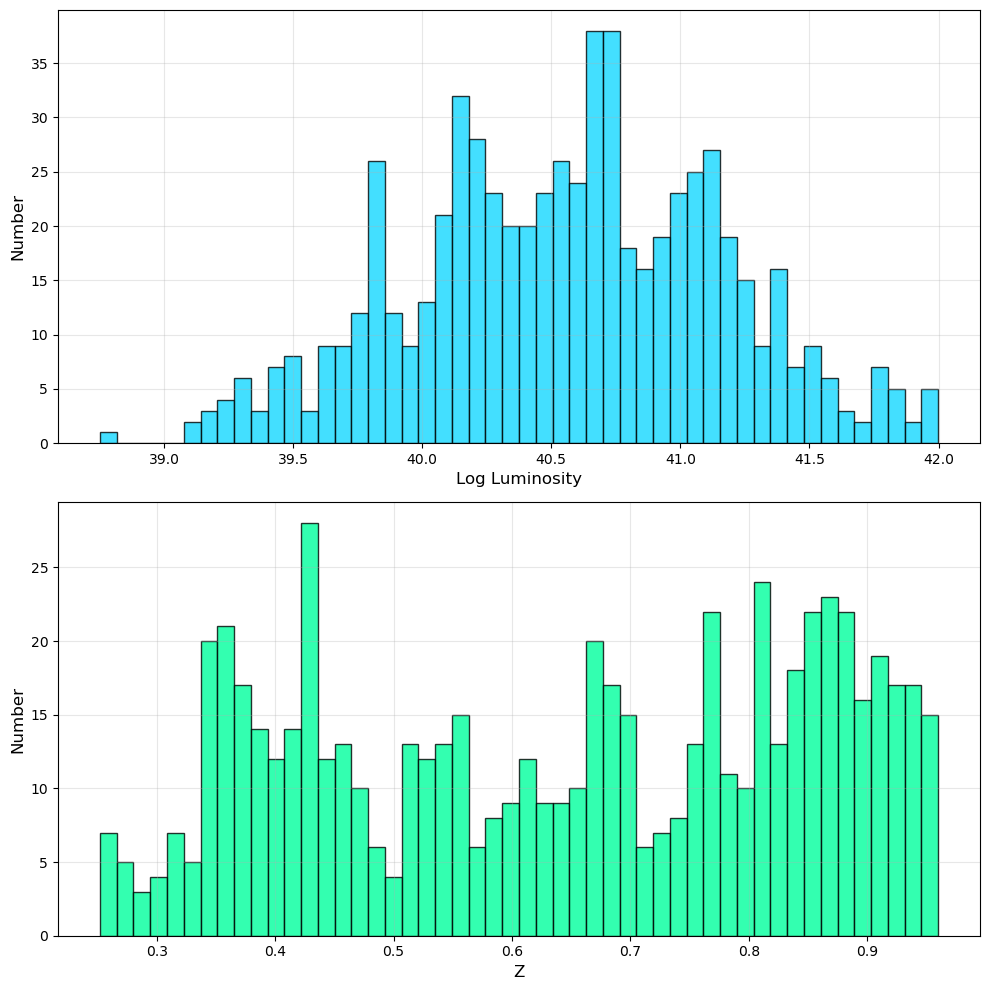

In [8]:
"""
This plot is just an intial look at the data.
"""
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

ax[0].hist(np.log10(Data["AGN_Only_Luminosities"]), bins=50, alpha=0.8,
        color=Colors["Teal"], edgecolor='black')

ax[0].set_xlabel('Log Luminosity', fontsize=12)
ax[0].set_ylabel('Number', fontsize=12)
ax[0].grid(True, alpha=0.3)



ax[1].hist((Data["Redshifts"]), bins=50, alpha=0.8,
        color=Colors["Green"], edgecolor='black')

ax[1].set_xlabel('Z', fontsize=12)
ax[1].set_ylabel('Number', fontsize=12)
ax[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()





# <font color='#7C00FE' size=3 >The first thing I notice is that the number of sources per redshift is relatively constant with a scater of around maybe 10. Whereas the luminosity varies quite a bit. Peaking around 40.5.</font>

# <font color='#FE81D4' size=5 >Setting up the Model</font>

In [9]:
"""
Finding the distribution of the luminosities for each redshift groups.
"""
#Splitting into redshift groups
Z_025_035 = []
Z_035_045 = []
Z_045_055 = []
Z_055_065 = []
Z_065_075 = []
Z_075_085 = []
Z_085_096 = []

Index_025_035 = []
Index_035_045 = []
Index_045_055 = []
Index_055_065 = []
Index_065_075 = []
Index_075_085 = []
Index_085_096 = []

a = -1
for i in Data["Redshifts"]:
    a = a+1
    #print(i)
    if 0.25 <= i < 0.35:
        #print(i)
        Z_025_035.append(i)
        Index_025_035.append(a)
    if 0.35 <= i < 0.45:
        Z_035_045.append(i)
        Index_035_045.append(a)
    if 0.45 <= i < 0.55:
        Z_045_055.append(i)
        Index_045_055.append(a)
    if 0.55 <= i < 0.65:
        Z_055_065.append(i)
        Index_055_065.append(a)
    if 0.65 <= i < 0.75:
        Z_065_075.append(i)
        Index_065_075.append(a)
    if 0.75 <= i < 0.85:
        Z_075_085.append(i)
        Index_075_085.append(a)
    if 0.85<= i <= 0.96:
        Z_085_096.append(i)
        Index_085_096.append(a)
    else:
        continue


Redshift_Indexes = {"025_035": {"Value": Z_025_035, "Index": Index_025_035},
                    "035_045": {"Value": Z_035_045, "Index": Index_035_045},
                    "045_055": {"Value": Z_045_055, "Index": Index_045_055},
                    "055_065": {"Value": Z_055_065, "Index": Index_055_065},
                    "065_075": {"Value": Z_065_075, "Index": Index_065_075},
                    "075_085": {"Value": Z_075_085, "Index": Index_075_085},
                    "085_096": {"Value": Z_085_096, "Index": Index_085_096},
                   }


#Getting the distribution in each of the redshift bins
Sigma_Luminosities = (np.log10(1 + Data["AGN_Only_Luminosities_Errors"] / Data["AGN_Only_Luminosities"]))

Sigma_Luminosities_Biweight_025_035 = biweight_location(Sigma_Luminosities[Redshift_Indexes["025_035"]["Index"]])
Sigma_Luminosities_Biweight_035_045 = biweight_location(Sigma_Luminosities[Redshift_Indexes["035_045"]["Index"]])
Sigma_Luminosities_Biweight_045_055 = biweight_location(Sigma_Luminosities[Redshift_Indexes["045_055"]["Index"]])
Sigma_Luminosities_Biweight_055_065 = biweight_location(Sigma_Luminosities[Redshift_Indexes["055_065"]["Index"]])
Sigma_Luminosities_Biweight_065_075 = biweight_location(Sigma_Luminosities[Redshift_Indexes["065_075"]["Index"]])
Sigma_Luminosities_Biweight_075_085 = biweight_location(Sigma_Luminosities[Redshift_Indexes["075_085"]["Index"]])
Sigma_Luminosities_Biweight_085_096 = biweight_location(Sigma_Luminosities[Redshift_Indexes["085_096"]["Index"]])


Luminosity_Spread_Binned = {"025_035": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_025_035, "Number": len(Redshift_Indexes["025_035"]["Index"])},
                            "035_045": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_035_045, "Number": len(Redshift_Indexes["035_045"]["Index"])},
                            "045_055": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_045_055, "Number": len(Redshift_Indexes["045_055"]["Index"])},
                            "055_065": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_055_065, "Number": len(Redshift_Indexes["055_065"]["Index"])},
                            "065_075": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_065_075, "Number": len(Redshift_Indexes["065_075"]["Index"])},
                            "075_085": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_075_085, "Number": len(Redshift_Indexes["075_085"]["Index"])},
                            "085_096": {"Sigma_Luminosities": Sigma_Luminosities_Biweight_085_096, "Number": len(Redshift_Indexes["085_096"]["Index"])},
                           }

print(min(Data["AGN_Only_Luminosities"]), max(Data["AGN_Only_Luminosities"]))

d_L_all = cosmo.luminosity_distance(Data["Redshifts"]).to('cm').value
F_lambda_all = Data["AGN_Only_Luminosities"] / (4 * np.pi * d_L_all**2)
print("Min F_lambda:", F_lambda_all.min())
print("Max F_lambda:", F_lambda_all.max())
print("Median F_lambda:", np.median(F_lambda_all))




F_lambda_limit = np.median(F_lambda_all)  # 2.18e-17 erg/s/cm²/Å

z_test       = 0.3175
d_L          = cosmo.luminosity_distance(z_test).to('cm').value
lambda_cm    = 3000e-8
c_cm         = 3e10
F_nu         = F_lambda_limit * lambda_cm**2 / c_cm
L_nu_3000    = 4 * np.pi * d_L**2 * F_nu
L_nu_1450    = L_nu_3000 * (1450/3000)**-0.61
M_1450       = -2.5 * np.log10(L_nu_1450) + 51.6
print("M_1450 at flux limit:", M_1450)
print("")
print("")
# Derive correct zero point
d_10pc_cm = 10 * 3.0857e18  # 10 parsecs in cm
zero_point = 2.5 * np.log10(4 * np.pi * d_10pc_cm**2) - 48.6
print("Correct zero point:", zero_point)

# Test with your flux limit
F_nu_lim  = F_lambda_limit * lambda_cm**2 / c_cm
L_nu_3000 = 4 * np.pi * d_L**2 * F_nu_lim
L_nu_1450 = L_nu_3000 * (1450/3000)**-0.61
M_1450    = -2.5 * np.log10(L_nu_1450) + zero_point
print("Zero point:", zero_point)
print("M_1450:", M_1450)

print("")
print("")
print("")
# What F_lambda corresponds to M_1450 = -22 at z=0.3?
M_test     = -22
L_nu_test  = 10**((51.6 - M_test) / 2.5)
L_nu_3000  = L_nu_test * (3000/1450)**-0.61
L_lam_3000 = L_nu_3000 * c_cm / lambda_cm**2
F_lam_test = L_lam_3000 / (4 * np.pi * d_L**2)
print("F_lambda for M_1450=-22 at z=0.3:", F_lam_test)

# And what M_1450 does your brightest object correspond to?
F_nu_max  = F_lambda_all.max() * lambda_cm**2 / c_cm
L_nu_max  = 4 * np.pi * d_L**2 * F_nu_max
L_nu_1450 = L_nu_max * (1450/3000)**-0.61
M_1450_max = -2.5 * np.log10(L_nu_1450) + 51.6
print("M_1450 for brightest object:", M_1450_max)

print()
print("AAAAAAAAA")
print("")

print("Sample L_3000 range:", Data["AGN_Only_Luminosities"].min(), Data["AGN_Only_Luminosities"].max())
print("Units should be erg/s/Å")

# What does a typical quasar L_3000 look like?
M_typical  = -22
L_nu_1450  = 10**((51.6 - M_typical) / 2.5)
L_nu_3000  = L_nu_1450 * (3000/1450)**-0.61
L_lam_3000 = L_nu_3000 * c_cm / lambda_cm**2
print("Typical quasar L_3000:", L_lam_3000)

5.650989703978614e+38 9.959813449905147e+41
Min F_lambda: 2.1296530993046948e-18
Max F_lambda: 8.40011053287493e-16
Median F_lambda: 2.1815637569848018e-17
M_1450 at flux limit: 0.28617914739360373


Correct zero point: 51.59479316260232
Zero point: 51.59479316260232
M_1450: 0.28097230999592426



F_lambda for M_1450=-22 at z=0.3: 1.7915938743578103e-08
M_1450 for brightest object: -3.677613579716045

AAAAAAAAA

Sample L_3000 range: 5.650989703978614e+38 9.959813449905147e+41
Units should be erg/s/Å
Typical quasar L_3000: 5.892088498382036e+48


In [10]:
"""
Turining the HETDEX flux limit into Luminosity.
The HETDEX flux limit is:  4.0×10⁻¹⁷ erg/s/cm²
"""

Luminosity_Limit_Per_Redshift_HETDEX = calculate_limiting_luminosity(Data["Redshifts"], HETDEX_Flux_Limit)


In [11]:
"""
Turning the Luminosity per redshift limit of HETDEX to ABSOLUTE magnitude.
"""

Magnitude_Limit_Per_Redshift_HETDEX = luminosity_to_absolute_mag(Luminosity_Limit_Per_Redshift_HETDEX)


# <font color='#FE81D4' size=5 >The Model</font>

In [12]:
"""
Running the Malmquist correction model.
This model spits out the correction factor and the correction factor errors for luminosity.
"""
Malmquist_Corrections = malmquist_correction_model(Redshift_Indexes, 1.0) #Table_Magnitudes["AGN_Mag"] and Table_Magnitudes["AGN_Mag_Error"]

Model_Corrected_Luminosities, Model_Corrected_Luminosities_Error = apply_malmquist_correction(Data, Redshift_Indexes, Malmquist_Corrections)



Bin 025_035: z=0.318, sigma_logL=0.0439, dlogPhi/dM=0.3454, delta_logL=0.0003, L_correction=1.0006
Bin 035_045: z=0.400, sigma_logL=0.0561, dlogPhi/dM=0.3435, delta_logL=0.0004, L_correction=1.0010
Bin 045_055: z=0.504, sigma_logL=0.0423, dlogPhi/dM=0.3413, delta_logL=0.0002, L_correction=1.0006
Bin 055_065: z=0.602, sigma_logL=0.0596, dlogPhi/dM=0.3393, delta_logL=0.0005, L_correction=1.0011
Bin 065_075: z=0.693, sigma_logL=0.0451, dlogPhi/dM=0.3375, delta_logL=0.0003, L_correction=1.0006
Bin 075_085: z=0.804, sigma_logL=0.0388, dlogPhi/dM=0.3355, delta_logL=0.0002, L_correction=1.0005
Bin 085_096: z=0.900, sigma_logL=0.0525, dlogPhi/dM=0.3338, delta_logL=0.0004, L_correction=1.0008


In [13]:
print(len(Model_Corrected_Luminosities), len(Malmquist_Corrections), len(Data["Redshifts"]), len(Redshift_Indexes["025_035"]["Value"]))
print(Malmquist_Corrections["035_045"]["sigma_log_10_luminosity"]["Value"])

653 7 653 51
0.05609341157498577


# <font color='#FE81D4' size=5 >Plotting the results from the model</font>

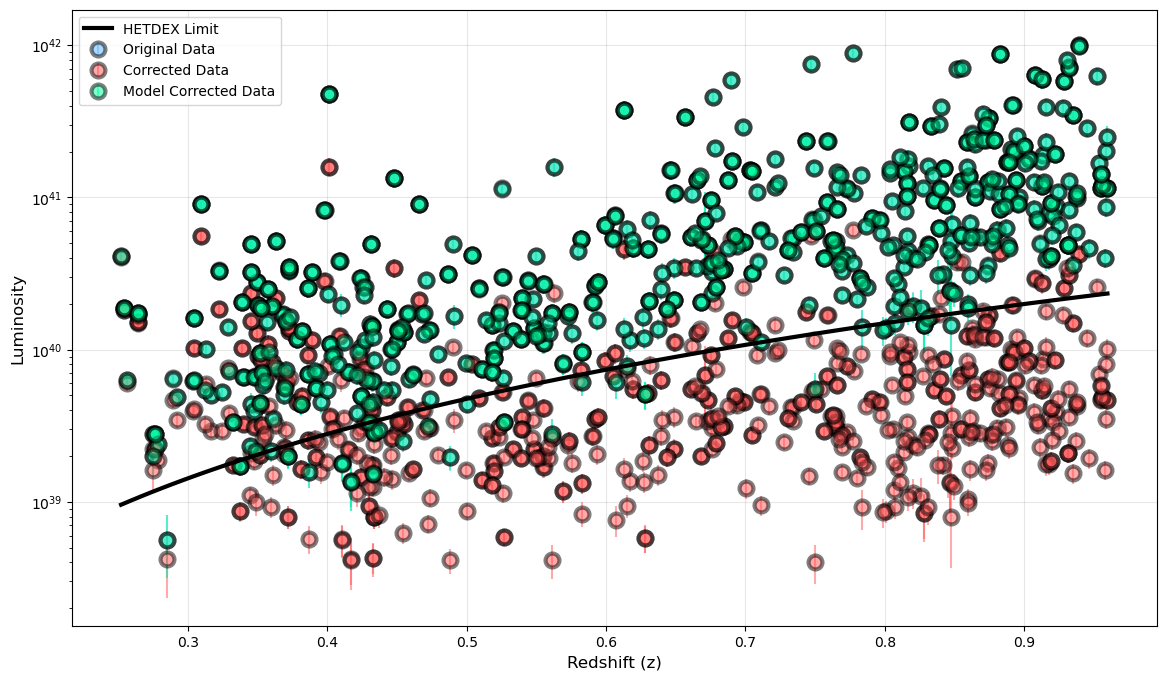

In [25]:
"""

"""
#Setting up needed stuff for plotting.
Markersize = 10
Markeredgewidth = 3
lw = 3

Z_Range = np.linspace(Data["Redshifts"].min(), Data["Redshifts"].max(), 100)
Luminosity_HETDEX_Limit = calculate_limiting_luminosity(Z_Range, flux_limit = HETDEX_Flux_Limit)

#Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

ax.errorbar(Data["Redshifts"], Data["AGN_Only_Luminosities"], yerr = Data["AGN_Only_Luminosities_Errors"],
            fmt = "o", alpha = 0.5, markersize = Markersize, color = Colors["Blue"], markeredgecolor = "black",
            markeredgewidth = Markeredgewidth, label = "Original Data")

ax.errorbar(Data["Redshifts"], Data["Corrected_AGN_Only_Luminosities"], yerr = Data["Corrected_AGN_Only_Luminosities_Errors"],
            fmt = "o", alpha = 0.5, markersize = Markersize, color = Colors["Red"], markeredgecolor = "black",
            markeredgewidth = Markeredgewidth, label = "Corrected Data")

ax.errorbar(Data["Redshifts"], Model_Corrected_Luminosities, yerr = Model_Corrected_Luminosities_Error,
            fmt = "o", alpha = 0.5, markersize = Markersize, color = Colors["Green"], markeredgecolor = "black",
            markeredgewidth = Markeredgewidth, label = "Model Corrected Data")


ax.plot(Z_Range, Luminosity_HETDEX_Limit / np.sqrt(50), "-", linewidth = lw, color = "black", label = "HETDEX Limit", zorder = 100)


ax.set_yscale('log')
ax.set_xlabel('Redshift (z)', fontsize=12)
ax.set_ylabel('Luminosity', fontsize=12)
#ax.set_title('Original vs Corrected Comparison', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)



In [ ]:
3.5 flux limit for one wave bin -- integrate many bin for continuum (50 bin) error improved sqrt(50)

integrated lum for Kulkarni -- 

Send plot to Karl ^

In [15]:
corr = Malmquist_Corrections["025_035"]
print("representative_redshift_per_bin:", corr["representative_redshift_per_bin"])
print("M_limit_per_bin:", corr["M_limit_per_bin"])
print("sigma_log_10_luminosity:", corr["sigma_log_10_luminosity"])
print("derivative_phi_star:", corr["derivative_phi_star"])
print("Delta_M:", corr["Delta_M"])
print("delta_log_10_luminosity:", corr["delta_log_10_luminosity"])
print("luminosity_correction_factor:", corr["luminosity_correction_factor"])

representative_redshift_per_bin: 0.317510642062337
M_limit_per_bin: [-0.22715553]
sigma_log_10_luminosity: {'Value': 0.04394876242894236, 'Error': 0.00031980326878105445}
derivative_phi_star: {'Value': 0.3453776996173777, 'Upper_Error': 0.5263028991827918, 'Lower_Error': 0.555103538129349}
Delta_M: {'Value': -0.0006670948575059347, 'Upper_Error': 0.0010165971035785075, 'Lower_Error': 0.0010722229516226499}
delta_log_10_luminosity: {'Value': 0.00026683794300237385, 'Upper_Error': 0.000406638841431403, 'Lower_Error': 0.00042888918064905995}
luminosity_correction_factor: {'Value': 1.0006146058626342, 'Upper_Error': 0.0009368960026021341, 'Lower_Error': 0.000988160790284943}


In [16]:
z_test = 0.3175
L_lim = calculate_limiting_luminosity(z_test, HETDEX_Flux_Limit)
print("L_lim:", L_lim)
M_lim = luminosity_to_absolute_mag(L_lim)
print("M_lim:", M_lim)


L_lim: 1.151059402440138e+40
M_lim: [-0.22707119]


In [17]:
lambda_3000_cm = 3000 * 10**-8
c_in_cm        = 3.0 * 10**10

L_nu_3000 = L_lim * lambda_3000_cm**2 / c_in_cm
print("L_nu_3000:", L_nu_3000)

L_nu_1450 = L_nu_3000 * (1450/3000)**-0.61
print("L_nu_1450:", L_nu_1450)

M_1450 = -2.5 * np.log10(L_nu_1450) + 51.6
print("M_1450:", M_1450)


L_nu_3000: 3.453178207320414e+20
L_nu_1450: 5.380572349377384e+20
M_1450: -0.227071188680533


In [18]:
print("L_lim / Angstrom check:", 1.3e40 / (3e-5)**2 * 3e10)

L_lim / Angstrom check: 4.333333333333334e+59


In [19]:
print("HETDEX_Flux_Limit:", HETDEX_Flux_Limit)

HETDEX_Flux_Limit: 3.5e-17


In [20]:
# What L_nu does M_1450 = -22 correspond to?
M_test = -22
L_nu_test = 10**((51.6 - M_test) / 2.5)
print("L_nu for M_1450=-22:", L_nu_test)

# And what flux limit corresponds to your L_lim?
L_nu_lim = 3.946e+20
M_lim_check = -2.5 * np.log10(L_nu_lim) + 51.6
print("M_lim from your L_nu:", M_lim_check)

# What should HETDEX faintest AGN be?
print("Expected M_1450 range for HETDEX AGN:", )

L_nu for M_1450=-22: 2.754228703338152e+29
M_lim from your L_nu: 0.109607297709573
Expected M_1450 range for HETDEX AGN:


In [21]:
z_test       = 0.3175
d_L          = cosmo.luminosity_distance(z_test).to('cm').value
F_lambda     = 4e-17                        # erg/s/cm²/Å
lambda_cm    = 3000e-8                      # cm
c_cm         = 3e10                         # cm/s
F_nu         = F_lambda * lambda_cm**2 / c_cm   # erg/s/cm²/Hz
L_nu_3000    = 4 * np.pi * d_L**2 * F_nu   # erg/s/Hz
alpha_nu     = -0.61
L_nu_1450    = L_nu_3000 * (1450/3000)**alpha_nu
M_1450       = -2.5 * np.log10(L_nu_1450) + 51.6
print("F_nu:", F_nu)
print("L_nu_3000:", L_nu_3000)
print("L_nu_1450:", L_nu_1450)
print("M_1450:", M_1450)

F_nu: 1.2e-36
L_nu_3000: 3.9464893797947585e+20
L_nu_1450: 6.149225542145582e+20
M_1450: -0.37205105612475364


In [22]:
# Work backwards from a known M_1450 ~ -22 AGN at z=0.3
M_1450_typical = -22
L_nu_1450_typical = 10**((51.6 - M_1450_typical) / 2.5)
L_nu_3000_typical = L_nu_1450_typical * (1450/3000)**(-0.61)  # reverse the SED
F_nu_typical = L_nu_3000_typical / (4 * np.pi * d_L**2)
F_lambda_typical = F_nu_typical * c_cm / lambda_cm**2
print("Typical AGN F_lambda at z=0.3:", F_lambda_typical)
print("HETDEX flux limit:", 4e-17)
print("Ratio:", F_lambda_typical / 4e-17)

Typical AGN F_lambda at z=0.3: 4.3496923113779104e-08
HETDEX flux limit: 4e-17
Ratio: 1087423077.8444774


In [23]:
# HETDEX resolution element ~ 5 Å
resolution_element = 5.0  # Å
F_lambda_corrected = 4e-17 / resolution_element
print("Corrected F_lambda:", F_lambda_corrected)

# Redo the M_1450 calculation
F_nu_corrected  = F_lambda_corrected * lambda_cm**2 / c_cm
L_nu_3000       = 4 * np.pi * d_L**2 * F_nu_corrected
L_nu_1450       = L_nu_3000 * (1450/3000)**-0.61
M_1450          = -2.5 * np.log10(L_nu_1450) + 51.6
print("M_1450 corrected:", M_1450)

Corrected F_lambda: 8e-18
M_1450 corrected: 1.3753739547152932
